In [187]:
from datascience import *
import numpy as np


import matplotlib.pyplot as plt

%matplotlib inline

In [188]:
def differnce_of_means(table, numeric_label, category_label):
    """
        Takes :
            - name of table
            - column label of numeric variable
            - column label of categorical variable

    returns : differnce of Variables of two groups
    """
    # Table with relevant columns
    reduced = table.select(category_label, numeric_label)

    # Table Containing Group Means
    means_table = reduced.group(category_label, collect=np.mean)

    # Array of Groups Table
    means = means_table.column(1)

    return means.item(1) - means.item(0)

In [189]:
# Permutation Test
def one_simulated_differnce(table, numeric_label, category_label):
    shuffled_labels = table.sample(with_replacement=False).column(category_label)
    shuffled_table = table.select(numeric_label).with_column("Shuffled Label", shuffled_labels)
    return differnce_of_means(shuffled_table, numeric_label, "Shuffled Label")

In [190]:
births = Table.read_table("baby.csv")
births.show(3)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


In [191]:
botox = Table.read_table("bta.csv")
botox.show(10)

Group,Result
Control,1
Control,1
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0
Control,0


In [192]:
botox.group("Group", collect=sum)

Group,Result sum
Control,2
Treatment,9


In [193]:
botox.pivot("Result", "Group")

Group,0.0,1.0
Control,14,2
Treatment,6,9


In [194]:
botox.pivot("Result", "Group")

Group,0.0,1.0
Control,14,2
Treatment,6,9


In [195]:
botox.group("Group", np.average)

Group,Result average
Control,0.125
Treatment,0.6


In [196]:
observed_differnce = differnce_of_means(botox, "Result", "Group")
observed_differnce

0.475

In [197]:
one_simulated_differnce(botox, "Result", "Group")

-0.17083333333333334

In [198]:
diffs = make_array()

for i in range(10_000):
    diffs = np.append(diffs, one_simulated_differnce(botox, "Result", "Group"))

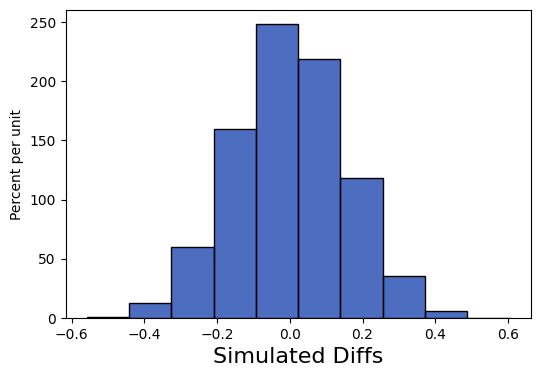

In [199]:
diffs_tab = Table().with_column("Simulated Diffs", diffs)
diffs_tab.hist()

In [200]:
observed_differnce

0.475

In [201]:
p_val = 1

((np.sum(diffs >= observed_differnce) / diffs_tab.num_rows))*100

0.71000000000000008